In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from itertools import combinations
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from torch.utils.data import TensorDataset, DataLoader
from joblib import Parallel, delayed

In [2]:
# ─── Utilities ────────────────────────────────────────────────────────────────
lam, p, niter = 1e4, 0.01, 10
def baseline_als(y):
    L = len(y)
    D = np.diff(np.eye(L), 2)
    D = lam * D.dot(D.T)
    w = np.ones(L)
    for _ in range(niter):
        b = np.linalg.solve(np.diag(w) + D, w * y)
        w = p * (y > b) + (1 - p) * (y < b)
    return b

def preprocess_raman_single(spectrum):
    """
    Raman tower: baseline-correct → L2-normalize → abs.
    (Same as your original preprocess_single.)
    """
    b = baseline_als(spectrum)
    c = spectrum - b
    norm = np.linalg.norm(c)
    out = c / norm if norm > 0 else c
    return np.abs(out)

def preprocess_fft_single(spectrum):
    """
    FFT tower: baseline-correct → FFT magnitude (log1p) → L2-normalize.
    Must match what you used when training siamese_mixture_fft.pth.
    """
    b = baseline_als(spectrum)
    c = spectrum - b
    fft_vals = np.fft.rfft(c)
    mag = np.abs(fft_vals)
    mag = np.log1p(mag)
    norm = np.linalg.norm(mag)
    out = mag / norm if norm > 0 else mag
    return out

def floatify_cols(df):
    new = []
    for c in df.columns:
        if c in ('Label', 'Label 1', 'Label 2'):
            new.append(c)
        else:
            new.append(float(c))
    df.columns = new

In [3]:
# ─── 1) Load reference_v2 ─────────────────────────────────────────────────────
ref_df = pd.read_csv('reference_v2.csv')
floatify_cols(ref_df)
wav_cols   = [c for c in ref_df.columns if c != 'Label']
ref_specs  = ref_df[wav_cols].values       # (n_ref_samples, n_waves)
ref_labels = ref_df['Label'].values        # (n_ref_samples,)

# Unique chemical classes
classes    = sorted(np.unique(ref_labels))
C = len(classes)
class_to_i = {c:i for i,c in enumerate(classes)}

In [ ]:
# ─── 2) Generate synthetic mixtures (raw domain) ──────────────────────────────
ratios = np.arange(0.05, 1.0, 0.05)
noise_level = 0.01
n_per_ratio = 10

synth_specs = []
synth_labels = []
for (i, ci), (j, cj) in combinations(enumerate(classes), 2):
    idx_i = np.where(ref_labels == ci)[0]
    idx_j = np.where(ref_labels == cj)[0]
    for r in ratios:
        for _ in range(n_per_ratio):
            spec_i = ref_specs[np.random.choice(idx_i)]
            spec_j = ref_specs[np.random.choice(idx_j)]
            mix = r * spec_i + (1-r) * spec_j
            mix += np.random.normal(scale=noise_level, size=mix.shape)
            synth_specs.append(mix)
            synth_labels.append((ci, cj))
synth_specs = np.array(synth_specs)
print("Synthetic raw spectra:", synth_specs.shape)

Synthetic raw spectra: (12540, 1024)


In [5]:
# ─── 3) Build Raman + FFT inputs for synthetic ────────────────────────────────
synth_raman = np.vstack(
    Parallel(n_jobs=-1, verbose=5)(
        delayed(preprocess_raman_single)(spec) for spec in synth_specs
    )
)
print("Synthetic Raman preproc:", synth_raman.shape)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done  98 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    7.6s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   12.5s
[Parallel(n_jobs=-1)]: Done 584 tasks      | elapsed:   18.5s
[Parallel(n_jobs=-1)]: Done 818 tasks      | elapsed:   25.7s
[Parallel(n_jobs=-1)]: Done 1088 tasks      | elapsed:   33.7s
[Parallel(n_jobs=-1)]: Done 1394 tasks      | elapsed:   42.9s
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:   53.2s
[Parallel(n_jobs=-1)]: Done 2114 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 2528 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 2978 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 3464 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 3986 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done 4544 tasks      | e

Synthetic Raman preproc: (12540, 1024)


[Parallel(n_jobs=-1)]: Done 12540 out of 12540 | elapsed:  6.4min finished


In [6]:
synth_fft = np.vstack(
    Parallel(n_jobs=-1, verbose=5)(
        delayed(preprocess_fft_single)(spec) for spec in synth_specs
    )
)
print("Synthetic FFT preproc:", synth_fft.shape)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done  98 tasks      | elapsed:    3.6s
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    7.3s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   12.4s
[Parallel(n_jobs=-1)]: Done 584 tasks      | elapsed:   18.4s
[Parallel(n_jobs=-1)]: Done 818 tasks      | elapsed:   25.6s
[Parallel(n_jobs=-1)]: Done 1088 tasks      | elapsed:   33.8s
[Parallel(n_jobs=-1)]: Done 1394 tasks      | elapsed:   43.2s
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:   53.7s
[Parallel(n_jobs=-1)]: Done 2114 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 2528 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 2978 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 3464 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 3986 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done 4544 tasks      | e

Synthetic FFT preproc: (12540, 513)


[Parallel(n_jobs=-1)]: Done 12540 out of 12540 | elapsed:  6.4min finished


In [7]:
# ─── 4) Siamese architecture (shared definition) ─────────────────────────────
class SiameseNet(nn.Module):
    def __init__(self, input_len, embed_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1,16,7,padding=3), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(16,32,5,padding=2), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Flatten(),
            nn.Linear((input_len//4)*32, embed_dim),
            nn.ReLU()
        )
    def forward(self,x):
        z = self.encoder(x)
        return F.normalize(z, dim=1)

# Raman Siamese (trained on Raman features)
siamese_raman = SiameseNet(input_len=ref_specs.shape[1], embed_dim=64)
siamese_raman.load_state_dict(torch.load('siamese_mixture.pth', map_location='cpu'))
siamese_raman.eval()

# FFT Siamese (trained on FFT features)
input_len_fft = synth_fft.shape[1]
siamese_fft = SiameseNet(input_len=input_len_fft, embed_dim=64)
siamese_fft.load_state_dict(torch.load('siamese_mixture_fft.pth', map_location='cpu'))
siamese_fft.eval()

SiameseNet(
  (encoder): Sequential(
    (0): Conv1d(1, 16, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=4096, out_features=64, bias=True)
    (8): ReLU()
  )
)

In [8]:
# ─── 5) Embed synthetic mixtures with BOTH towers ────────────────────────────
with torch.no_grad():
    ten_raman = torch.tensor(synth_raman, dtype=torch.float32).unsqueeze(1)
    emb_raman = siamese_raman(ten_raman).cpu().numpy()   # (N, 64)

    ten_fft   = torch.tensor(synth_fft, dtype=torch.float32).unsqueeze(1)
    emb_fft   = siamese_fft(ten_fft).cpu().numpy()       # (N, 64)

In [9]:
# Concatenate embeddings: [Emb A | Emb B]
syn_embeds = np.hstack([emb_raman, emb_fft])            # (N, 128)
print("Concatenated embeddings:", syn_embeds.shape)

Concatenated embeddings: (12540, 128)


In [10]:
# ─── 6) Build X_synth, Y_synth ────────────────────────────────────────────────
N = len(syn_embeds)
X_synth = syn_embeds
Y_synth = np.zeros((N, C), dtype=int)
for k, (ci, cj) in enumerate(synth_labels):
    Y_synth[k, class_to_i[ci]] = 1
    Y_synth[k, class_to_i[cj]] = 1

In [11]:
# ─── 7) Split into train/val/test ─────────────────────────────────────────────
X_tmp, X_test_s, Y_tmp, Y_test_s = train_test_split(
    X_synth, Y_synth, test_size=0.10, random_state=0
)
X_train_s, X_val_s, Y_train_s, Y_val_s = train_test_split(
    X_tmp, Y_tmp, test_size=0.1111, random_state=0
)
print("Synthetic train/val/test:", len(X_train_s), len(X_val_s), len(X_test_s))

Synthetic train/val/test: 10032 1254 1254


In [12]:
# ─── 8) DataLoaders ───────────────────────────────────────────────────────────
batch_size = 64
train_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_train_s, dtype=torch.float32),
        torch.tensor(Y_train_s, dtype=torch.float32)
    ),
    batch_size=batch_size,
    shuffle=True
)
val_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_val_s, dtype=torch.float32),
        torch.tensor(Y_val_s, dtype=torch.float32)
    ),
    batch_size=batch_size
)
test_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_test_s, dtype=torch.float32),
        torch.tensor(Y_test_s, dtype=torch.float32)
    ),
    batch_size=batch_size
)

In [13]:
# ─── 9) MLP on concatenated embeddings ────────────────────────────────────────
class PresenceNetLogits(nn.Module):
    def __init__(self, D, C):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(D, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, C)   # raw logits
        )
    def forward(self, x):
        return self.net(x)

D = X_train_s.shape[1]   # should be 128 (64 + 64)
C = len(classes)
model_boost = PresenceNetLogits(D, C)

In [14]:
# pos_weight (class imbalance)
pos = Y_train_s.sum(axis=0)
neg = len(Y_train_s) - pos
pos_weight = torch.tensor((neg/pos).clip(min=1.0), dtype=torch.float32)
print("pos_weight:", pos_weight)

pos_weight: tensor([4.9714, 5.0726, 5.0216, 4.9928, 5.0800, 4.9326, 5.1096, 5.0000, 4.9361,
        4.9750, 5.0144, 4.9012])


In [15]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model_boost.parameters(), lr=1e-3)

num_epochs = 200
for epoch in range(1, num_epochs+1):
    model_boost.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        logits = model_boost(xb)
        loss = criterion(logits, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)

    model_boost.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            logits = model_boost(xb)
            val_loss += criterion(logits, yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    print(f"Epoch {epoch}/{num_epochs} — "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 1/200 — Train Loss: 0.9130 | Val Loss: 0.6710
Epoch 2/200 — Train Loss: 0.5963 | Val Loss: 0.5324
Epoch 3/200 — Train Loss: 0.5049 | Val Loss: 0.4723
Epoch 4/200 — Train Loss: 0.4589 | Val Loss: 0.4405
Epoch 5/200 — Train Loss: 0.4260 | Val Loss: 0.4100
Epoch 6/200 — Train Loss: 0.4003 | Val Loss: 0.3913
Epoch 7/200 — Train Loss: 0.3804 | Val Loss: 0.3724
Epoch 8/200 — Train Loss: 0.3636 | Val Loss: 0.3563
Epoch 9/200 — Train Loss: 0.3488 | Val Loss: 0.3417
Epoch 10/200 — Train Loss: 0.3359 | Val Loss: 0.3272
Epoch 11/200 — Train Loss: 0.3240 | Val Loss: 0.3216
Epoch 12/200 — Train Loss: 0.3134 | Val Loss: 0.3087
Epoch 13/200 — Train Loss: 0.3043 | Val Loss: 0.2989
Epoch 14/200 — Train Loss: 0.2949 | Val Loss: 0.2900
Epoch 15/200 — Train Loss: 0.2873 | Val Loss: 0.2811
Epoch 16/200 — Train Loss: 0.2802 | Val Loss: 0.2747
Epoch 17/200 — Train Loss: 0.2742 | Val Loss: 0.2687
Epoch 18/200 — Train Loss: 0.2675 | Val Loss: 0.2641
Epoch 19/200 — Train Loss: 0.2615 | Val Loss: 0.2565
Ep

In [35]:
from pathlib import Path

save_path = Path("presence_net_logits.pth")

ckpt = {
    "model_state_dict": model_boost.state_dict(),
    "D": D,
    "C": C,
    "classes": classes,                 # list of class names in order
    "pos_weight": pos_weight.cpu(),     # optional but useful
    "epoch": num_epochs,
    # Optional: if you want to resume training later
    "optimizer_state_dict": optimizer.state_dict(),
}

torch.save(ckpt, save_path)
print(f"Saved checkpoint to: {save_path.resolve()}")

Saved checkpoint to: /home/elfo/Documents/NRC/NRC_SU25_Spectral_Classification/Mixture_Classification/Notebooks/presence_net_logits.pth


In [16]:
# ─── 10) Real mixtures: build Raman + FFT, embed, concat, classify ───────────
mix_df = pd.read_csv('mixtures_dataset.csv')
floatify_cols(mix_df)

wav_cols = [c for c in mix_df.columns if c not in ('Label 1', 'Label 2')]
mix_specs = mix_df[wav_cols].values.astype(float)

mix_raman = np.vstack(
    Parallel(n_jobs=-1, verbose=5)(
        delayed(preprocess_raman_single)(spec) for spec in mix_specs
    )
)
print("Mixtures Raman preproc:", mix_raman.shape)

mix_fft = np.vstack(
    Parallel(n_jobs=-1, verbose=5)(
        delayed(preprocess_fft_single)(spec) for spec in mix_specs
    )
)
print("Mixtures FFT preproc:", mix_fft.shape)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done  98 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    7.3s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   12.2s
[Parallel(n_jobs=-1)]: Done 580 out of 580 | elapsed:   17.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


Mixtures Raman preproc: (580, 1024)


[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done  98 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    7.3s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   12.0s


Mixtures FFT preproc: (580, 513)


[Parallel(n_jobs=-1)]: Done 580 out of 580 | elapsed:   17.5s finished


In [50]:
with torch.no_grad():
    mix_emb_raman = siamese_raman(
        torch.tensor(mix_raman, dtype=torch.float32).unsqueeze(1)
    ).cpu().numpy()
    mix_emb_fft = siamese_fft(
        torch.tensor(mix_fft, dtype=torch.float32).unsqueeze(1)
    ).cpu().numpy()

mix_embeds = np.hstack([mix_emb_raman, mix_emb_fft])   # (N_real, 128)

pairs = list(zip(mix_df['Label 1'], mix_df['Label 2']))
N_real = len(mix_df)
Y_real = np.zeros((N_real, C), dtype=int)
for i, (l1, l2) in enumerate(pairs):
    Y_real[i, class_to_i[l1]] = 1
    Y_real[i, class_to_i[l2]] = 1

device = next(model_boost.parameters()).device  # cuda or cpu

model_boost.eval()
with torch.no_grad():
    X = torch.tensor(mix_embeds, dtype=torch.float32, device=device)
    preds = model_boost(X).detach().cpu().numpy()   # back to cpu for numpy
Y_pred_real = (preds > 0.0).astype(int)


supports = Y_real.sum(axis=0)
valid_idx = [i for i, s in enumerate(supports) if s > 0]
valid_labels = [classes[i] for i in valid_idx]

y_true_filt = Y_real[:, valid_idx]
y_pred_filt = Y_pred_real[:, valid_idx]

print("\nReal Mixtures Validation Report (labels with support > 0):")
print(classification_report(
    y_true_filt,
    y_pred_filt,
    target_names=valid_labels,
    zero_division=0
))


Real Mixtures Validation Report (labels with support > 0):
                       precision    recall  f1-score   support

      1-dodecanethiol       0.87      0.99      0.92       243
 6-mercapto-1-hexanol       0.94      0.85      0.89       108
              benzene       1.00      1.00      1.00       193
         benzenethiol       0.67      1.00      0.80        72
                 etoh       1.00      1.00      1.00       121
                 meoh       1.00      0.99      0.99       243
n,n-dimethylformamide       0.99      1.00      0.99        72
             pyridine       1.00      1.00      1.00       108

            micro avg       0.94      0.98      0.96      1160
            macro avg       0.93      0.98      0.95      1160
         weighted avg       0.95      0.98      0.96      1160
          samples avg       0.95      0.98      0.96      1160



In [18]:
import numpy as np
import torch

model_boost.eval()
with torch.no_grad():
    logits = model_boost(torch.tensor(mix_embeds, dtype=torch.float32)).cpu().numpy()  # (N, C)

# Convert logits -> probabilities
probs = 1 / (1 + np.exp(-logits))

# Use prob threshold (0.5)
thr = 0.5
Y_pred_real = (probs >= thr).astype(int)

# (Optional) equivalently, threshold logits at 0.0:
# Y_pred_real = (logits >= 0.0).astype(int)


/tmp/ipykernel_1009285/2182551093.py:9: RuntimeWarning: overflow encountered in exp
  probs = 1 / (1 + np.exp(-logits))


In [61]:
from collections import Counter

target_label = "6-mercapto-1-hexanol"
k = class_to_i[target_label]

true_pos = (Y_real[:, k] == 1)          # mercapto truly present
pred_neg = (probs[:, k] < thr)          # model did NOT predict mercapto
fn_mask = true_pos & pred_neg           # false negatives for mercapto
fn_idx = np.where(fn_mask)[0]

print("Mercapto false negatives:", len(fn_idx), "out of", int(true_pos.sum()), "true mercapto samples")

# Top-2 predicted labels for each FN (by probability)
top2_idx = np.argsort(probs[fn_idx], axis=1)[:, -2:][:, ::-1]  # indices of top2, descending

top2_labels = [tuple(classes[j] for j in row) for row in top2_idx]  # (label1, label2) tuples
pair_counts = Counter(top2_labels)

print("\nMost common TOP-2 predicted label pairs for mercapto FNs:")
for pair, cnt in pair_counts.most_common(15):
    print(f"{cnt:4d}  {pair}")

# Also: which single labels appear most in top2 (helps see dominant confusion class)
single_counts = Counter([lbl for pair in top2_labels for lbl in pair])

print("\nMost common individual labels appearing in TOP-2 for mercapto FNs:")
for lbl, cnt in single_counts.most_common(15):
    print(f"{cnt:4d}  {lbl}")

# Optional: print a few example rows with their true pair + top2 predictions + mercapto score
print("\nExamples (index | true labels | mercapto prob | top2 preds):")
for i in fn_idx[:10]:
    true_pair = tuple([classes[j] for j in np.where(Y_real[i] == 1)[0]])
    top2 = tuple(classes[j] for j in np.argsort(probs[i])[-2:][::-1])
    print(i, "|", true_pair, "|", f"{probs[i, k]:.3f}", "|", top2)


Mercapto false negatives: 16 out of 108 true mercapto samples

Most common TOP-2 predicted label pairs for mercapto FNs:
  16  ('benzene', '1-dodecanethiol')

Most common individual labels appearing in TOP-2 for mercapto FNs:
  16  benzene
  16  1-dodecanethiol

Examples (index | true labels | mercapto prob | top2 preds):
0 | ('6-mercapto-1-hexanol', 'benzene') | 0.486 | ('benzene', '1-dodecanethiol')
3 | ('6-mercapto-1-hexanol', 'benzene') | 0.444 | ('benzene', '1-dodecanethiol')
5 | ('6-mercapto-1-hexanol', 'benzene') | 0.477 | ('benzene', '1-dodecanethiol')
7 | ('6-mercapto-1-hexanol', 'benzene') | 0.481 | ('benzene', '1-dodecanethiol')
9 | ('6-mercapto-1-hexanol', 'benzene') | 0.496 | ('benzene', '1-dodecanethiol')
10 | ('6-mercapto-1-hexanol', 'benzene') | 0.486 | ('benzene', '1-dodecanethiol')
14 | ('6-mercapto-1-hexanol', 'benzene') | 0.490 | ('benzene', '1-dodecanethiol')
16 | ('6-mercapto-1-hexanol', 'benzene') | 0.489 | ('benzene', '1-dodecanethiol')
18 | ('6-mercapto-1-hexan

Mercapto score stats:
  positives: mean= 0.8136873841285706 median= 0.9470090866088867
  negatives: mean= 0.017019815742969513 median= 3.1491565550822997e-06


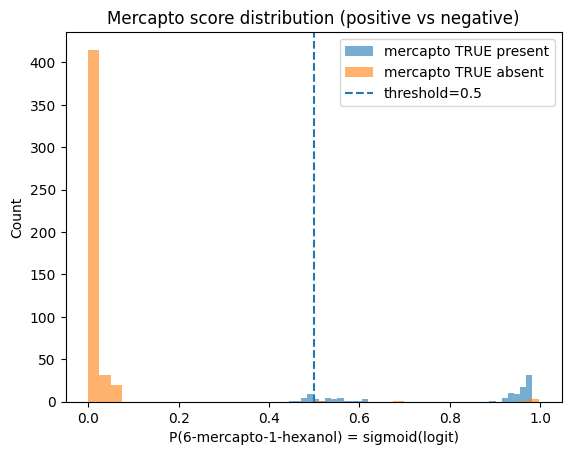

In [62]:
import matplotlib.pyplot as plt

pos_scores = probs[true_pos, k]      # P(mercapto) when mercapto is truly present
neg_scores = probs[~true_pos, k]     # P(mercapto) when mercapto is truly absent

print("Mercapto score stats:")
print("  positives: mean=", float(pos_scores.mean()), "median=", float(np.median(pos_scores)))
print("  negatives: mean=", float(neg_scores.mean()), "median=", float(np.median(neg_scores)))

plt.figure()
plt.hist(pos_scores, bins=40, alpha=0.6, label="mercapto TRUE present")
plt.hist(neg_scores, bins=40, alpha=0.6, label="mercapto TRUE absent")
plt.axvline(thr, linestyle="--", label=f"threshold={thr}")
plt.xlabel("P(6-mercapto-1-hexanol) = sigmoid(logit)")
plt.ylabel("Count")
plt.title("Mercapto score distribution (positive vs negative)")
plt.legend()
plt.show()


In [63]:
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(true_pos.astype(int), probs[:, k])
print("Mercapto ROC-AUC:", auc)


Mercapto ROC-AUC: 0.9912115505335845


In [66]:
device = next(model_boost.parameters()).device
model_boost.eval()

yp, yt = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)                 # <-- move inputs to model device
        # yb can stay on cpu if you only use numpy later; or move then cpu() back

        logits = model_boost(xb)           # (B, C)
        yp.append(logits.detach().cpu().numpy())
        yt.append(yb.detach().cpu().numpy())

y_pred = (np.vstack(yp) > 0.0).astype(int)  # logits>0 ↔ prob>=0.5
y_true = np.vstack(yt).astype(int)

print("\nSynthetic Test Classification Report:")
print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))



Synthetic Test Classification Report:
                              precision    recall  f1-score   support

           1,9-nonanedithiol       0.85      0.95      0.89       196
             1-dodecanethiol       0.53      0.96      0.69       225
             1-undecanethiol       0.48      0.93      0.63       208
        6-mercapto-1-hexanol       0.67      0.97      0.80       204
                     benzene       1.00      1.00      1.00       235
                benzenethiol       0.95      0.99      0.97       195
                        dmmp       1.00      1.00      1.00       220
                        etoh       0.94      0.98      0.96       217
                        meoh       0.90      0.99      0.95       184
       n,n-dimethylformamide       1.00      0.98      0.99       212
                    pyridine       1.00      1.00      1.00       223
tris(2-ethylhexyl) phosphate       0.98      1.00      0.99       189

                   micro avg       0.81      0.98

In [23]:
model_boost.eval()
all_logits, all_true = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        all_logits.append(model_boost(xb).cpu().numpy())  # logits
        all_true.append(yb.cpu().numpy())                 # 0/1 labels

logits = np.vstack(all_logits)   # (N_test, C)
y_true = np.vstack(all_true)     # (N_test, C)

# probs = sigmoid(logits)
probs = 1 / (1 + np.exp(-logits))

thr = 0.5
y_pred = (probs >= thr).astype(int)   # prediction based on probability
# equivalent: y_pred = (logits >= 0.0).astype(int)


/tmp/ipykernel_1009285/3806194797.py:13: RuntimeWarning: overflow encountered in exp
  probs = 1 / (1 + np.exp(-logits))


In [ ]:
def analyze_label(k, label_name, y_true, probs, thr=0.5, topk_pairs=10, plot=False, bins=40):
    true_pos = (y_true[:, k] == 1)
    pred_neg = (probs[:, k] < thr)
    fn_mask = true_pos & pred_neg
    fn_idx = np.where(fn_mask)[0]

    n_pos = int(true_pos.sum())
    n_fn  = len(fn_idx)

    # ROC-AUC (only valid if both classes exist)
    auc = None
    if len(np.unique(true_pos.astype(int))) == 2:
        auc = roc_auc_score(true_pos.astype(int), probs[:, k])

    # Score stats
    pos_scores = probs[true_pos, k]
    neg_scores = probs[~true_pos, k]

    print("\n" + "="*80)
    print(f"Label: {label_name}  (index {k})")
    print(f"Positives: {n_pos} | False Negatives @ thr={thr}: {n_fn} ({(n_fn/max(n_pos,1))*100:.1f}%)")
    if auc is not None:
        print(f"ROC-AUC: {auc:.4f}")

    print("Score stats:")
    print(f"  positives: mean={float(pos_scores.mean()):.4f}  median={float(np.median(pos_scores)):.4f}")
    print(f"  negatives: mean={float(neg_scores.mean()):.6f}  median={float(np.median(neg_scores)):.6f}")

    # Where do FNs go? (top-2 predicted labels in each FN sample)
    if n_fn > 0:
        top2_idx = np.argsort(probs[fn_idx], axis=1)[:, -2:][:, ::-1]
        top2_labels = [tuple(classes[j] for j in row) for row in top2_idx]
        pair_counts = Counter(top2_labels)

        print("\nMost common TOP-2 predicted label pairs for FNs:")
        for pair, cnt in pair_counts.most_common(topk_pairs):
            print(f"{cnt:4d}  {pair}")

        single_counts = Counter([lbl for pair in top2_labels for lbl in pair])
        print("\nMost common individual labels appearing in TOP-2 for FNs:")
        for lbl, cnt in single_counts.most_common(topk_pairs):
            print(f"{cnt:4d}  {lbl}")

        print("\nExamples (index | true labels | P(this label) | top2 preds):")
        for i in fn_idx[:10]:
            true_pair = tuple([classes[j] for j in np.where(y_true[i] == 1)[0]])
            top2 = tuple(classes[j] for j in np.argsort(probs[i])[-2:][::-1])
            print(i, "|", true_pair, "|", f"{probs[i, k]:.3f}", "|", top2)

    # Plot histogram
    if plot:
        plt.figure()
        plt.hist(pos_scores, bins=bins, alpha=0.6, label=f"{label_name} TRUE present")
        plt.hist(neg_scores, bins=bins, alpha=0.6, label=f"{label_name} TRUE absent")
        plt.axvline(thr, linestyle="--", label=f"threshold={thr}")
        plt.xlabel(f"P({label_name}) = sigmoid(logit)")
        plt.ylabel("Count")
        plt.title(f"{label_name} score distribution (positive vs negative)")
        plt.legend()
        plt.show()

# Run for every label
for k, label_name in enumerate(classes):
    analyze_label(k, label_name, y_true, probs, thr=0.5, topk_pairs=10, plot=False)



Label: 1,9-nonanedithiol  (index 0)
Positives: 196 | False Negatives @ thr=0.5: 10 (5.1%)
ROC-AUC: 0.9954
Score stats:
  positives: mean=0.9195  median=0.9999
  negatives: mean=0.057086  median=0.000004

Most common TOP-2 predicted label pairs for FNs:
   7  ('benzene', '6-mercapto-1-hexanol')
   2  ('n,n-dimethylformamide', '6-mercapto-1-hexanol')
   1  ('dmmp', '6-mercapto-1-hexanol')

Most common individual labels appearing in TOP-2 for FNs:
  10  6-mercapto-1-hexanol
   7  benzene
   2  n,n-dimethylformamide
   1  dmmp

Examples (index | true labels | P(this label) | top2 preds):
41 | ('1,9-nonanedithiol', 'n,n-dimethylformamide') | 0.429 | ('n,n-dimethylformamide', '6-mercapto-1-hexanol')
104 | ('1,9-nonanedithiol', 'benzene') | 0.479 | ('benzene', '6-mercapto-1-hexanol')
107 | ('1,9-nonanedithiol', 'dmmp') | 0.222 | ('dmmp', '6-mercapto-1-hexanol')
245 | ('1,9-nonanedithiol', 'benzene') | 0.462 | ('benzene', '6-mercapto-1-hexanol')
461 | ('1,9-nonanedithiol', 'benzene') | 0.357 

In [25]:
summary = []
for k, label_name in enumerate(classes):
    true_pos = (y_true[:, k] == 1)
    pred_neg = (probs[:, k] < thr)
    fn = int((true_pos & pred_neg).sum())
    tp = int((true_pos & (probs[:, k] >= thr)).sum())
    pos = int(true_pos.sum())
    recall = tp / (pos + 1e-12)

    auc = np.nan
    if len(np.unique(true_pos.astype(int))) == 2:
        auc = roc_auc_score(true_pos.astype(int), probs[:, k])

    summary.append((label_name, pos, recall, fn, auc))

summary_sorted = sorted(summary, key=lambda x: x[2])  # sort by recall
print("\nWorst recall labels @ thr=0.5:")
for row in summary_sorted[:8]:
    print(f"{row[0]:30s} pos={row[1]:4d} recall={row[2]:.3f} FN={row[3]:4d} AUC={row[4]:.3f}")



Worst recall labels @ thr=0.5:
1-undecanethiol                pos= 208 recall=0.928 FN=  15 AUC=0.916
1,9-nonanedithiol              pos= 196 recall=0.949 FN=  10 AUC=0.995
1-dodecanethiol                pos= 225 recall=0.964 FN=   8 AUC=0.960
6-mercapto-1-hexanol           pos= 204 recall=0.971 FN=   6 AUC=0.985
n,n-dimethylformamide          pos= 212 recall=0.981 FN=   4 AUC=1.000
etoh                           pos= 217 recall=0.982 FN=   4 AUC=0.999
meoh                           pos= 184 recall=0.995 FN=   1 AUC=0.999
benzenethiol                   pos= 195 recall=0.995 FN=   1 AUC=1.000


In [26]:
# --- Embed real mixtures ---
with torch.no_grad():
    mix_emb_raman = siamese_raman(
        torch.tensor(mix_raman, dtype=torch.float32).unsqueeze(1)
    ).cpu().numpy()
    mix_emb_fft = siamese_fft(
        torch.tensor(mix_fft, dtype=torch.float32).unsqueeze(1)
    ).cpu().numpy()

mix_embeds = np.hstack([mix_emb_raman, mix_emb_fft])   # (N_real, 128)

# --- Build Y_real ---
pairs = list(zip(mix_df['Label 1'], mix_df['Label 2']))
N_real = len(mix_df)
Y_real = np.zeros((N_real, C), dtype=int)
for i, (l1, l2) in enumerate(pairs):
    Y_real[i, class_to_i[l1]] = 1
    Y_real[i, class_to_i[l2]] = 1

# --- Model outputs on real mixtures (LOGITS) ---
model_boost.eval()
with torch.no_grad():
    logits = model_boost(torch.tensor(mix_embeds, dtype=torch.float32)).cpu().numpy()  # (N_real, C)

# probs = sigmoid(logits)
probs = 1 / (1 + np.exp(-logits))

thr = 0.5
Y_pred_real = (probs >= thr).astype(int)  # probability-based decision
# equivalent: Y_pred_real = (logits >= 0.0).astype(int)


/tmp/ipykernel_1009285/2502353186.py:26: RuntimeWarning: overflow encountered in exp
  probs = 1 / (1 + np.exp(-logits))


In [27]:
supports = Y_real.sum(axis=0)
valid_idx = [i for i, s in enumerate(supports) if s > 0]
valid_labels = [classes[i] for i in valid_idx]

y_true_filt = Y_real[:, valid_idx]
y_pred_filt = Y_pred_real[:, valid_idx]

print("\nReal Mixtures Validation Report (labels with support > 0):")
print(classification_report(
    y_true_filt,
    y_pred_filt,
    target_names=valid_labels,
    zero_division=0
))



Real Mixtures Validation Report (labels with support > 0):
                       precision    recall  f1-score   support

      1-dodecanethiol       0.87      0.99      0.92       243
 6-mercapto-1-hexanol       0.94      0.85      0.89       108
              benzene       1.00      1.00      1.00       193
         benzenethiol       0.67      1.00      0.80        72
                 etoh       1.00      1.00      1.00       121
                 meoh       1.00      0.99      0.99       243
n,n-dimethylformamide       0.99      1.00      0.99        72
             pyridine       1.00      1.00      1.00       108

            micro avg       0.94      0.98      0.96      1160
            macro avg       0.93      0.98      0.95      1160
         weighted avg       0.95      0.98      0.96      1160
          samples avg       0.95      0.98      0.96      1160



In [28]:
def analyze_label_on_real(k, label_name, Y_real, probs, thr=0.5, topk_pairs=10, plot=False, bins=40):
    true_pos = (Y_real[:, k] == 1)
    pred_neg = (probs[:, k] < thr)
    fn_mask = true_pos & pred_neg
    fn_idx = np.where(fn_mask)[0]

    n_pos = int(true_pos.sum())
    n_fn  = len(fn_idx)

    # ROC-AUC (only if both classes exist)
    auc = None
    if len(np.unique(true_pos.astype(int))) == 2:
        auc = roc_auc_score(true_pos.astype(int), probs[:, k])

    pos_scores = probs[true_pos, k]
    neg_scores = probs[~true_pos, k]

    print("\n" + "="*80)
    print(f"Label: {label_name}  (index {k})")
    print(f"Support: {n_pos} | False Negatives @ thr={thr}: {n_fn} ({(n_fn/max(n_pos,1))*100:.1f}%)")
    if auc is not None:
        print(f"ROC-AUC: {auc:.4f}")

    print("Score stats:")
    print(f"  positives: mean={float(pos_scores.mean()):.4f}  median={float(np.median(pos_scores)):.4f}")
    print(f"  negatives: mean={float(neg_scores.mean()):.6f}  median={float(np.median(neg_scores)):.6f}")

    # Where do FNs go? (top-2 predicted labels)
    if n_fn > 0:
        top2_idx = np.argsort(probs[fn_idx], axis=1)[:, -2:][:, ::-1]
        top2_labels = [tuple(classes[j] for j in row) for row in top2_idx]
        pair_counts = Counter(top2_labels)

        print("\nMost common TOP-2 predicted label pairs for FNs:")
        for pair, cnt in pair_counts.most_common(topk_pairs):
            print(f"{cnt:4d}  {pair}")

        single_counts = Counter([lbl for pair in top2_labels for lbl in pair])
        print("\nMost common individual labels appearing in TOP-2 for FNs:")
        for lbl, cnt in single_counts.most_common(topk_pairs):
            print(f"{cnt:4d}  {lbl}")

        print("\nExamples (index | true labels | P(this label) | top2 preds):")
        for i in fn_idx[:10]:
            true_pair = tuple([classes[j] for j in np.where(Y_real[i] == 1)[0]])
            top2 = tuple(classes[j] for j in np.argsort(probs[i])[-2:][::-1])
            print(i, "|", true_pair, "|", f"{probs[i, k]:.3f}", "|", top2)

    # Histogram (optional)
    if plot:
        plt.figure()
        plt.hist(pos_scores, bins=bins, alpha=0.6, label=f"{label_name} TRUE present")
        plt.hist(neg_scores, bins=bins, alpha=0.6, label=f"{label_name} TRUE absent")
        plt.axvline(thr, linestyle="--", label=f"threshold={thr}")
        plt.xlabel(f"P({label_name}) = sigmoid(logit)")
        plt.ylabel("Count")
        plt.title(f"{label_name} score distribution (positive vs negative)")
        plt.legend()
        plt.show()


# Run for all labels that actually appear in the real set
for k in valid_idx:
    analyze_label_on_real(k, classes[k], Y_real, probs, thr=thr, topk_pairs=10, plot=False)



Label: 1-dodecanethiol  (index 1)
Support: 243 | False Negatives @ thr=0.5: 3 (1.2%)
ROC-AUC: 0.9686
Score stats:
  positives: mean=0.8449  median=0.8975
  negatives: mean=0.081864  median=0.000000

Most common TOP-2 predicted label pairs for FNs:
   1  ('meoh', '1-undecanethiol')
   1  ('1,9-nonanedithiol', 'n,n-dimethylformamide')
   1  ('1,9-nonanedithiol', 'meoh')

Most common individual labels appearing in TOP-2 for FNs:
   2  meoh
   2  1,9-nonanedithiol
   1  1-undecanethiol
   1  n,n-dimethylformamide

Examples (index | true labels | P(this label) | top2 preds):
267 | ('1-dodecanethiol', 'meoh') | 0.439 | ('meoh', '1-undecanethiol')
400 | ('1-dodecanethiol', 'meoh') | 0.016 | ('1,9-nonanedithiol', 'n,n-dimethylformamide')
406 | ('1-dodecanethiol', 'meoh') | 0.269 | ('1,9-nonanedithiol', 'meoh')

Label: 6-mercapto-1-hexanol  (index 3)
Support: 108 | False Negatives @ thr=0.5: 16 (14.8%)
ROC-AUC: 0.9912
Score stats:
  positives: mean=0.8137  median=0.9470
  negatives: mean=0.017

In [29]:
summary = []
for k in valid_idx:
    true_pos = (Y_real[:, k] == 1)
    tp = int((true_pos & (probs[:, k] >= thr)).sum())
    fn = int((true_pos & (probs[:, k] <  thr)).sum())
    pos = int(true_pos.sum())
    recall = tp / (pos + 1e-12)

    auc = np.nan
    if len(np.unique(true_pos.astype(int))) == 2:
        auc = roc_auc_score(true_pos.astype(int), probs[:, k])

    summary.append((classes[k], pos, recall, fn, auc))

summary_sorted = sorted(summary, key=lambda x: x[2])  # sort by recall ascending

print("\nWorst recall labels on REAL mixtures @ thr=0.5:")
for name, pos, rec, fn, auc in summary_sorted[:10]:
    print(f"{name:30s} support={pos:4d} recall={rec:.3f} FN={fn:4d} AUC={auc:.3f}")



Worst recall labels on REAL mixtures @ thr=0.5:
6-mercapto-1-hexanol           support= 108 recall=0.852 FN=  16 AUC=0.991
1-dodecanethiol                support= 243 recall=0.988 FN=   3 AUC=0.969
meoh                           support= 243 recall=0.988 FN=   3 AUC=0.996
benzenethiol                   support=  72 recall=1.000 FN=   0 AUC=1.000
n,n-dimethylformamide          support=  72 recall=1.000 FN=   0 AUC=1.000
pyridine                       support= 108 recall=1.000 FN=   0 AUC=1.000
etoh                           support= 121 recall=1.000 FN=   0 AUC=1.000
benzene                        support= 193 recall=1.000 FN=   0 AUC=1.000


In [30]:
import numpy as np
import torch

# ---------- Synthetic test (from test_loader) ----------
model_boost.eval()
syn_logits_list, syn_true_list = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        syn_logits_list.append(model_boost(xb).cpu().numpy())  # logits
        syn_true_list.append(yb.cpu().numpy())                 # 0/1

logits_syn = np.vstack(syn_logits_list)      # (N_syn, C)
y_true_syn = np.vstack(syn_true_list).astype(int)
probs_syn  = 1 / (1 + np.exp(-logits_syn))   # sigmoid

# ---------- Real mixtures ----------
model_boost.eval()
with torch.no_grad():
    logits_real = model_boost(torch.tensor(mix_embeds, dtype=torch.float32)).cpu().numpy()
probs_real = 1 / (1 + np.exp(-logits_real))  # sigmoid


/tmp/ipykernel_1009285/2724202452.py:14: RuntimeWarning: overflow encountered in exp
  probs_syn  = 1 / (1 + np.exp(-logits_syn))   # sigmoid
/tmp/ipykernel_1009285/2724202452.py:20: RuntimeWarning: overflow encountered in exp
  probs_real = 1 / (1 + np.exp(-logits_real))  # sigmoid


In [31]:

def compare_pos_distributions_all_labels(classes, y_true_syn, probs_syn, Y_real, probs_real):
    rows = []
    for k, name in enumerate(classes):
        syn_pos = probs_syn[y_true_syn[:, k] == 1, k]
        real_pos = probs_real[Y_real[:, k] == 1, k]

        # Skip if a label is missing in either set
        if syn_pos.size == 0 or real_pos.size == 0:
            continue

        rows.append({
            "label": name,
            "syn_pos_n": int(syn_pos.size),
            "real_pos_n": int(real_pos.size),
            "syn_pos_median": float(np.median(syn_pos)),
            "real_pos_median": float(np.median(real_pos)),
            "syn_pos_mean": float(np.mean(syn_pos)),
            "real_pos_mean": float(np.mean(real_pos)),
            # Negative means real is lower => left shift
            "median_shift_real_minus_syn": float(np.median(real_pos) - np.median(syn_pos)),
            "mean_shift_real_minus_syn": float(np.mean(real_pos) - np.mean(syn_pos)),
        })

    df = pd.DataFrame(rows)
    df = df.sort_values("median_shift_real_minus_syn")  # most negative shifts first
    return df

df_shift = compare_pos_distributions_all_labels(classes, y_true_syn, probs_syn, Y_real, probs_real)

print("Largest LEFT shifts (real positives much lower than synthetic positives):")
print(df_shift[[
    "label", "syn_pos_n", "real_pos_n",
    "syn_pos_median", "real_pos_median",
    "median_shift_real_minus_syn",
    "syn_pos_mean", "real_pos_mean",
    "mean_shift_real_minus_syn"
]].head(12).to_string(index=False))


Largest LEFT shifts (real positives much lower than synthetic positives):
                label  syn_pos_n  real_pos_n  syn_pos_median  real_pos_median  median_shift_real_minus_syn  syn_pos_mean  real_pos_mean  mean_shift_real_minus_syn
      1-dodecanethiol        225         243        0.934566         0.897467                    -0.037099      0.876436       0.844948              -3.148800e-02
 6-mercapto-1-hexanol        204         108        0.983660         0.947009                    -0.036651      0.899464       0.813687              -8.577621e-02
         benzenethiol        195          72        1.000000         0.999121                    -0.000879      0.987575       0.998501               1.092541e-02
              benzene        235         193        1.000000         1.000000                     0.000000      1.000000       1.000000               5.960464e-08
                 etoh        217         121        1.000000         1.000000                     0.000000     

In [32]:
from sklearn.metrics import precision_score, recall_score

def best_threshold_fbeta(y_true_bin, p, beta=2.0, grid=None):
    if grid is None:
        grid = np.linspace(0.01, 0.99, 99)

    best_t, best_f = 0.5, -1.0
    for t in grid:
        y_pred = (p >= t).astype(int)
        tp = np.sum((y_true_bin==1) & (y_pred==1))
        fp = np.sum((y_true_bin==0) & (y_pred==1))
        fn = np.sum((y_true_bin==1) & (y_pred==0))
        prec = tp/(tp+fp+1e-12)
        rec  = tp/(tp+fn+1e-12)
        f = (1+beta**2)*prec*rec/(beta**2*prec + rec + 1e-12)
        if f > best_f:
            best_f, best_t = f, float(t)
    return best_t, best_f

rows = []
thr0 = 0.5

for k, name in enumerate(classes):
    yk = Y_real[:, k]
    if yk.sum() == 0:
        continue  # label absent in real set

    pk = probs_real[:, k]

    # baseline @ 0.5
    base_pred = (pk >= thr0).astype(int)
    base_prec = precision_score(yk, base_pred, zero_division=0)
    base_rec  = recall_score(yk, base_pred, zero_division=0)

    # optimized threshold
    t_opt, f_opt = best_threshold_fbeta(yk, pk, beta=2.0)
    opt_pred = (pk >= t_opt).astype(int)
    opt_prec = precision_score(yk, opt_pred, zero_division=0)
    opt_rec  = recall_score(yk, opt_pred, zero_division=0)

    rows.append({
        "label": name,
        "support": int(yk.sum()),
        "base_thr": thr0,
        "base_prec": float(base_prec),
        "base_rec": float(base_rec),
        "opt_thr_F2": float(t_opt),
        "opt_prec": float(opt_prec),
        "opt_rec": float(opt_rec),
        "recall_gain": float(opt_rec - base_rec),
        "precision_change": float(opt_prec - base_prec),
    })

df_thr = pd.DataFrame(rows).sort_values("recall_gain", ascending=False)

print("Biggest recall gains from per-label thresholding (F2-optimized):")
print(df_thr[[
    "label","support","base_prec","base_rec",
    "opt_thr_F2","opt_prec","opt_rec",
    "recall_gain","precision_change"
]].head(12).to_string(index=False))


Biggest recall gains from per-label thresholding (F2-optimized):
                label  support  base_prec  base_rec  opt_thr_F2  opt_prec  opt_rec  recall_gain  precision_change
 6-mercapto-1-hexanol      108   0.938776  0.851852        0.07  0.947368 1.000000     0.148148          0.008593
      1-dodecanethiol      243   0.869565  0.987654        0.01  0.870968 1.000000     0.012346          0.001403
              benzene      193   1.000000  1.000000        0.01  1.000000 1.000000     0.000000          0.000000
         benzenethiol       72   0.666667  1.000000        0.81  1.000000 1.000000     0.000000          0.333333
                 etoh      121   1.000000  1.000000        0.01  1.000000 1.000000     0.000000          0.000000
                 meoh      243   1.000000  0.987654        0.01  1.000000 0.987654     0.000000          0.000000
n,n-dimethylformamide       72   0.986301  1.000000        0.02  0.986301 1.000000     0.000000          0.000000
             pyridine  

In [67]:
merc = "6-mercapto-1-hexanol"
k = class_to_i[merc]

idx = np.where(Y_real[:, k] == 1)[0]          # indices where mercapto truly present
P = probs_real[idx]                           # (N_pos, C)

# rank 1 = best/highest prob
merc_scores = P[:, k]
# Count how many labels have strictly greater score than mercapto, add 1 => rank
ranks = (P > merc_scores[:, None]).sum(axis=1) + 1

print(f"{merc} rank on REAL positives (1=highest):")
print("  N positives:", len(idx))
print("  mean rank:", float(np.mean(ranks)))
print("  median rank:", float(np.median(ranks)))
print("  % rank<=2:", float(np.mean(ranks <= 2))*100)
print("  % rank<=3:", float(np.mean(ranks <= 3))*100)
print("  % rank<=4:", float(np.mean(ranks <= 4))*100)

# Optional: show most common ranks
unique_r, counts = np.unique(ranks, return_counts=True)
print("\nRank histogram (rank: count):")
for r, c in zip(unique_r[:10], counts[:10]):
    print(f"  {int(r)}: {int(c)}")

# Optional: for mercapto positives, who beats mercapto most often?
better = (P > merc_scores[:, None])  # (N_pos,C)
better[:, k] = False
counts_better = better.sum(axis=0)
top_confusers = np.argsort(counts_better)[::-1][:10]
print("\nLabels that outrank mercapto most often on mercapto-positive samples:")
for j in top_confusers:
    if counts_better[j] > 0:
        print(f"  {classes[j]:30s}  outranks mercapto in {int(counts_better[j])}/{len(idx)} samples")


6-mercapto-1-hexanol rank on REAL positives (1=highest):
  N positives: 108
  mean rank: 3.3333333333333335
  median rank: 3.0
  % rank<=2: 0.0
  % rank<=3: 66.66666666666666
  % rank<=4: 100.0

Rank histogram (rank: count):
  3: 72
  4: 36

Labels that outrank mercapto most often on mercapto-positive samples:
  1,9-nonanedithiol               outranks mercapto in 72/108 samples
  pyridine                        outranks mercapto in 36/108 samples
  benzene                         outranks mercapto in 36/108 samples
  n,n-dimethylformamide           outranks mercapto in 36/108 samples
  1-undecanethiol                 outranks mercapto in 36/108 samples
  1-dodecanethiol                 outranks mercapto in 36/108 samples


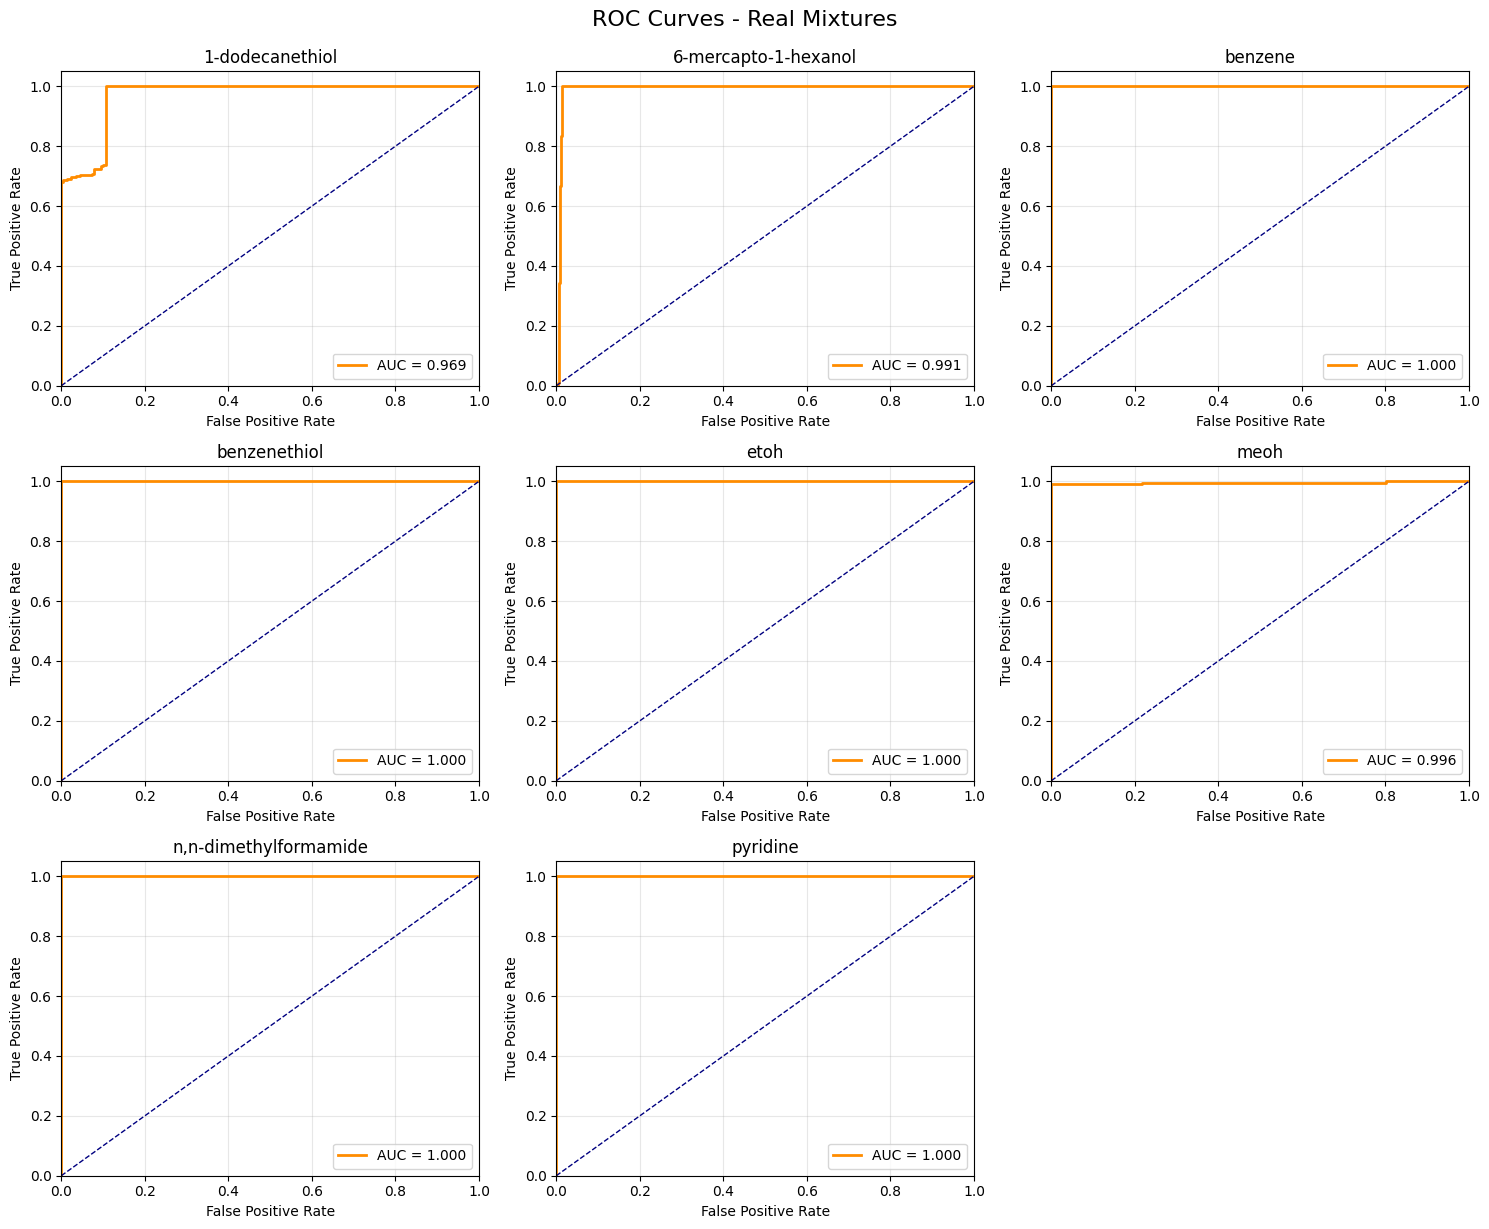

In [43]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np
import math

def plot_multi_label_roc(y_true, y_probs, class_names, title="ROC Curves"):
    """
    Plots ROC curves for all classes in a grid.
    y_true: (N, C) binary labels
    y_probs: (N, C) probabilities (0-1)
    class_names: list of C strings
    """
    n_classes = len(class_names)
    
    # Determine grid size (e.g., 3 columns)
    cols = 3
    rows = math.ceil(n_classes / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten()
    
    for i, ax in enumerate(axes):
        if i >= n_classes:
            ax.axis('off') # Hide unused subplots
            continue
            
        name = class_names[i]
        
        # Check if class is present in this dataset
        if np.sum(y_true[:, i]) == 0:
            ax.text(0.5, 0.5, 'No Positive Samples', 
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f"{name} (N/A)")
            continue
            
        # Calculate ROC
        fpr, tpr, _ = roc_curve(y_true[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        
        # Plot
        ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
        ax.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(f"{name}")
        ax.legend(loc="lower right")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.suptitle(title, y=1.02, fontsize=16)
    plt.show()

# --- USAGE ---
# This assumes you have run the "Real mixtures" section of your code 
# and have 'Y_real' (true labels) and 'probs' (model probabilities) ready.

# Filter to only show classes that actually exist in the real set to avoid empty plots
# (Optional: Only use if you want to skip the "No Positive Samples" plots)
present_indices = [i for i in range(len(classes)) if Y_real[:, i].sum() > 0]
present_classes = [classes[i] for i in present_indices]
present_Y = Y_real[:, present_indices]
present_probs = probs[:, present_indices]

# Plot
plot_multi_label_roc(present_Y, present_probs, present_classes, title="ROC Curves - Real Mixtures")

In [68]:
import pandas as pd
import numpy as np

mix_df = pd.read_csv("mixtures_dataset.csv")

# canonicalize pair order so (A,B) == (B,A)
l1 = mix_df["Label 1"].astype(str).str.strip()
l2 = mix_df["Label 2"].astype(str).str.strip()

a = np.where(l1 <= l2, l1, l2)
b = np.where(l1 <= l2, l2, l1)

mix_df["mixture"] = a + " + " + b

# counts for each distinct mixture
mix_counts = mix_df["mixture"].value_counts().sort_index()

print("Total samples:", len(mix_df))
print("Distinct mixtures:", mix_counts.shape[0])
print("\nDistinct mixtures (with counts):")
print(mix_counts.to_string())

# optional: save the recap
mix_counts.rename("count").to_csv("distinct_mixtures_counts.csv")
print("\nSaved: distinct_mixtures_counts.csv")


Total samples: 580
Distinct mixtures: 12

Distinct mixtures (with counts):
mixture
1-dodecanethiol + benzene                        49
1-dodecanethiol + etoh                           36
1-dodecanethiol + meoh                          158
6-mercapto-1-hexanol + benzene                   36
6-mercapto-1-hexanol + n,n-dimethylformamide     36
6-mercapto-1-hexanol + pyridine                  36
benzene + benzenethiol                           36
benzene + etoh                                   36
benzene + meoh                                   36
benzenethiol + pyridine                          36
etoh + meoh                                      49
n,n-dimethylformamide + pyridine                 36

Saved: distinct_mixtures_counts.csv
